# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [13]:
import numpy as np
import pandas as pd
import os
import sklearn
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("data/temps.csv")
df

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41
...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47
344,2016,12,28,Wed,42,47,45.3,48,58
345,2016,12,29,Thurs,47,48,45.3,48,65
346,2016,12,30,Fri,48,48,45.4,57,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 25.8 KB


In [16]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


In [17]:
# vamos a ver cositas del target

df['actual'].value_counts()

actual
57    16
60    16
68    16
65    13
55    12
71    12
52    11
59    11
64    11
67    11
51    10
77    10
49     9
63     9
76     9
66     9
75     9
48     8
54     8
53     8
61     8
73     8
56     7
58     7
74     7
40     6
62     6
81     6
79     6
69     5
80     5
72     5
45     4
44     4
50     4
46     4
85     4
70     4
41     3
82     3
42     3
39     3
47     2
87     2
78     2
83     2
35     2
89     1
92     1
86     1
88     1
90     1
84     1
36     1
43     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribución de la temperatura máxima (actual)')

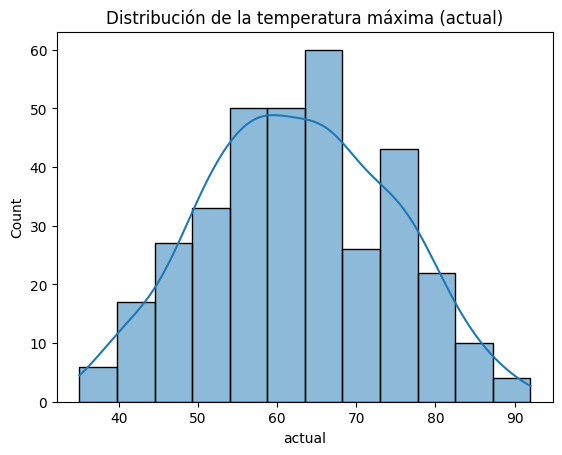

In [18]:
# voy a ver si el modelo tendrá que lidiar con colas, asimetrías, etc
sns.histplot(df['actual'], kde=True)
plt.title("Distribución de la temperatura máxima (actual)")


# pico claro entre 60-70
# simétrica

<Axes: xlabel='friend', ylabel='actual'>

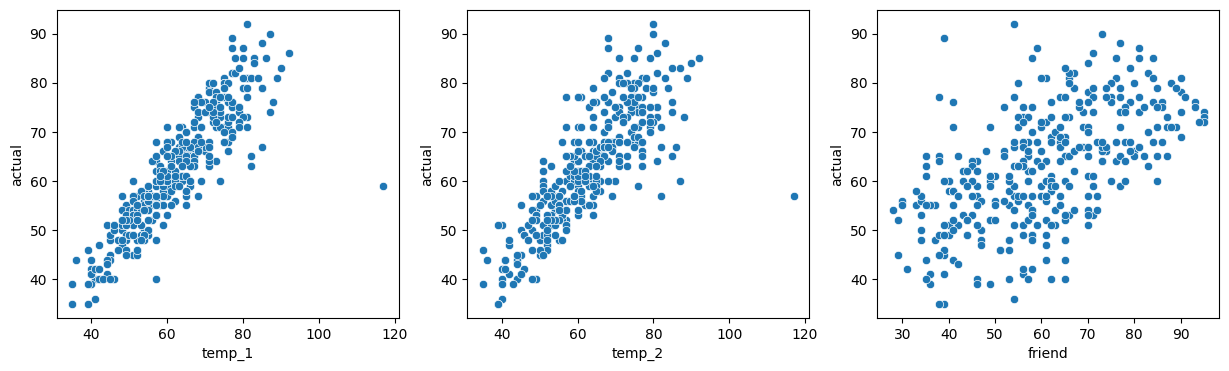

In [19]:
# relación de 'actual' con cada predictor
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x='temp_1', y='actual', ax=axes[0])
sns.scatterplot(data=df, x='temp_2', y='actual', ax=axes[1])
sns.scatterplot(data=df, x='friend', y='actual', ax=axes[2])


# scatter 1:
# relación casi lineal y muy fuerte
# cuanto más alta fue la temperatura de ayer, más alta es hoy

# scatter 2:
# relación fuerte, aunque algo más dispersa que la anterior
# no tan bueno como el anterior scatter

# scatter 3:
# lo del amigo chapas se ve bastante más disperso, mete bastante ruido

ValueError: Could not interpret value `week_int` for `x`. An entry with this name does not appear in `data`.

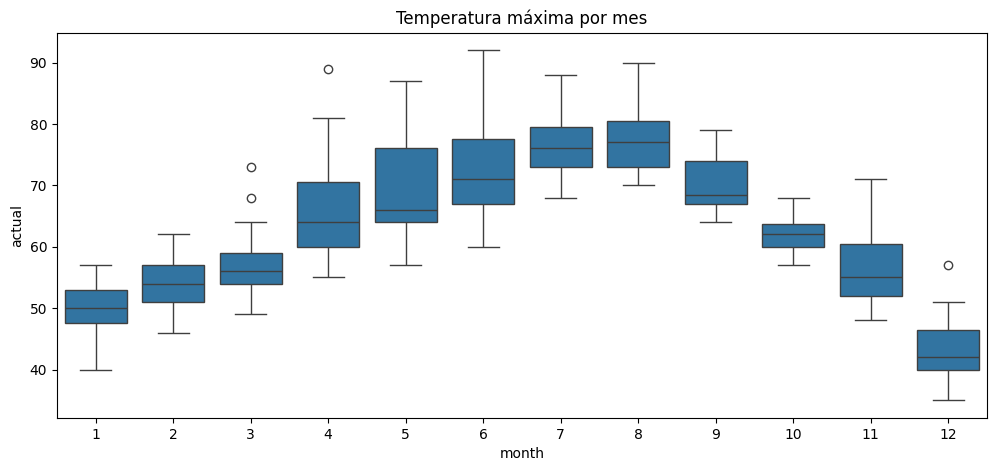

<Figure size 1000x500 with 0 Axes>

In [20]:
# voy a ver la estacionalidad y ver si hay patrones por mes, día...

# mes
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='month', y='actual')
plt.title("Temperatura máxima por mes")

# día de la semana
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='week_int', y='actual')
plt.title("Temperatura por día de la semana")



# por día de la semana no se observa ningún patrón, no es significativo

# pero por mes sí se ve un claro patrón 
# de los meses 6 al 8 se ve más temperaturas

In [22]:
df.corr(numeric_only=True)['actual'].sort_values(ascending=False)


actual     1.000000
temp_1     0.877880
average    0.848365
temp_2     0.805835
friend     0.569145
month      0.004529
day       -0.021675
year            NaN
Name: actual, dtype: float64

In [23]:
# voy a crear una columna con la diferencia entre días

df['dif_temp'] = df['temp_1'] - df['temp_2']


In [24]:
# ahora una con el error del chapas

df['error_chapas'] = df['friend'] - df['average']

In [25]:

df['temp_actual_avg'] = df['actual'] - df['average']


In [26]:
df.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'dif_temp', 'error_chapas', 'temp_actual_avg'],
      dtype='str')

In [27]:
df.head(5)

,year,month,day,week,temp_2,temp_1,average,actual,friend,dif_temp,error_chapas,temp_actual_avg
0,2016,1,1,Fri,45,45,45.6,45,29,0,-16.6,-0.6
1,2016,1,2,Sat,44,45,45.7,44,61,1,15.3,-1.7
2,2016,1,3,Sun,45,44,45.8,41,56,-1,10.2,-4.8
3,2016,1,4,Mon,44,41,45.9,40,53,-3,7.1,-5.9
4,2016,1,5,Tues,41,40,46.0,44,41,-1,-5.0,-2.0


<Axes: xlabel='error_chapas', ylabel='actual'>

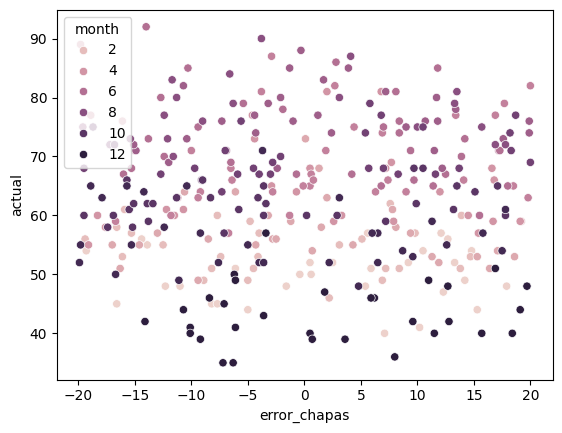

In [28]:
sns.scatterplot(data=df, x='error_chapas', y='actual', hue= 'month')

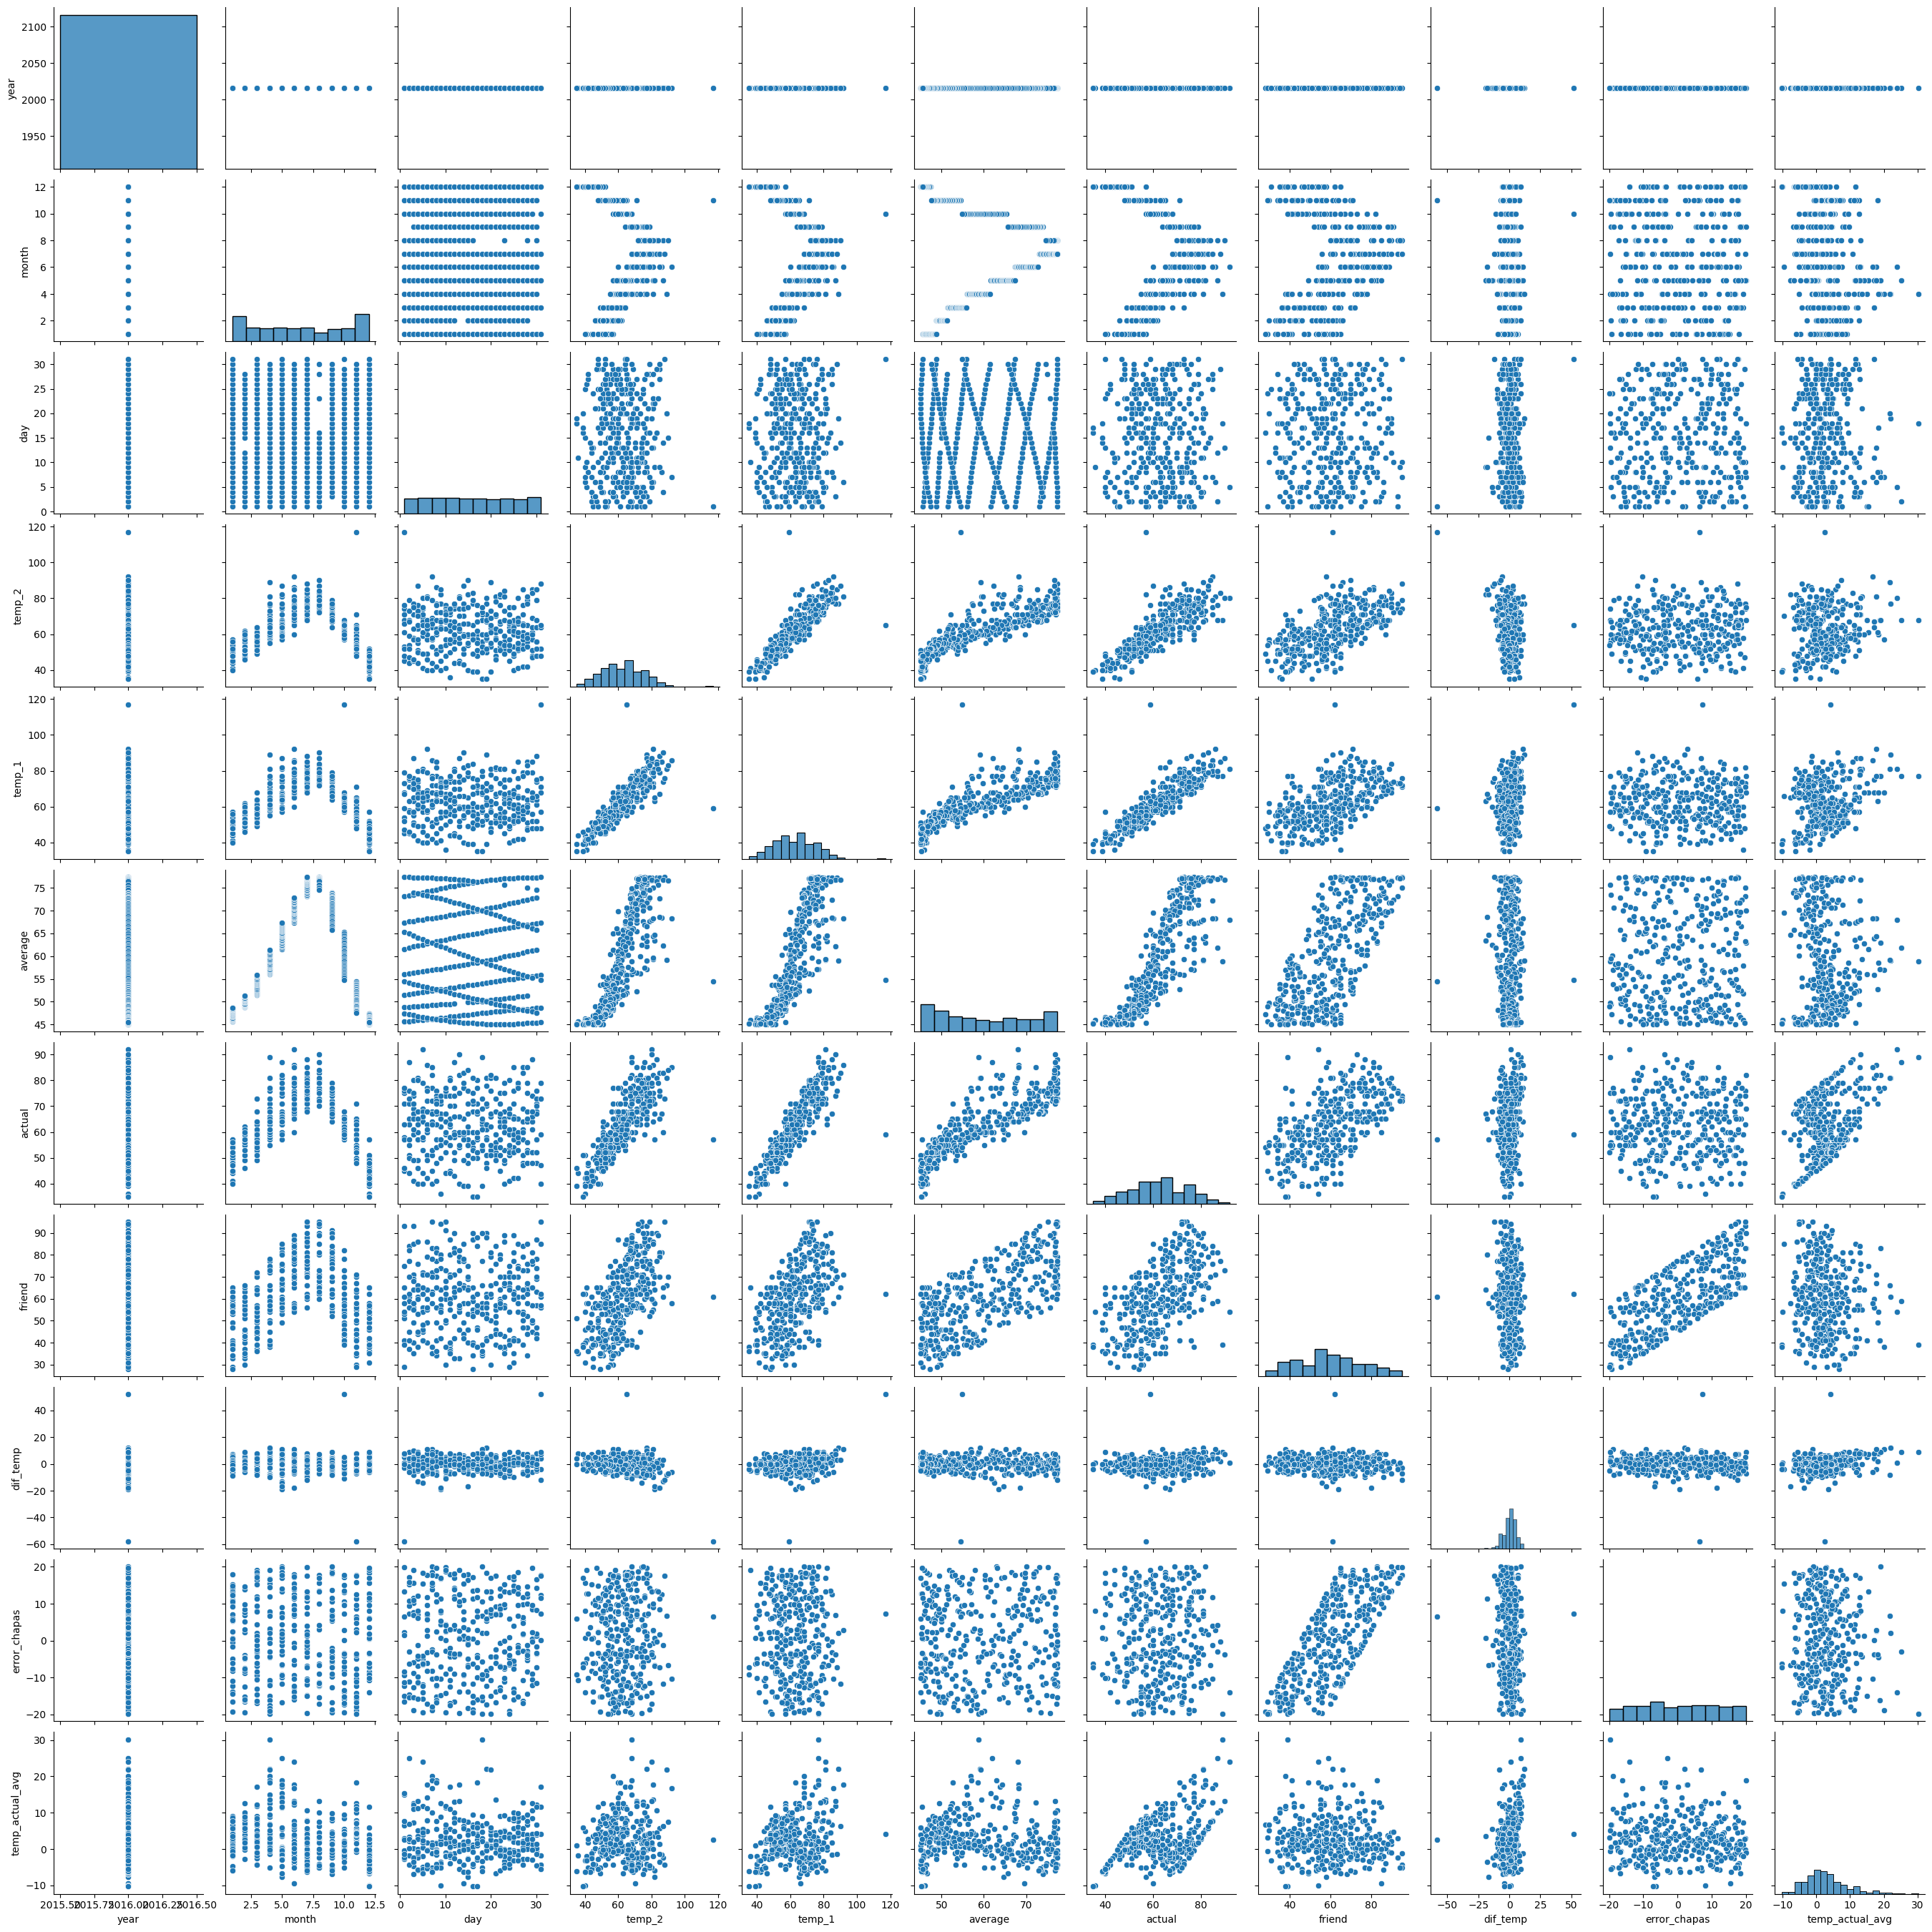

In [29]:
sns.pairplot(df)

<Axes: >

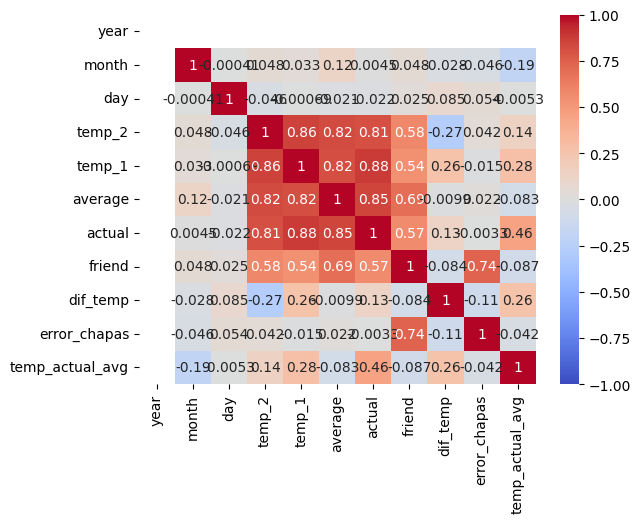

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

In [31]:
# transformo el día de la semana, que está en str, a int
# lunes 0 y domingo 6

# from sklearn.preprocessing import LabelEncoder
# encoder = LabelEncoder() # método para pasar categóricas a numéricas

df['week'].unique()

<ArrowStringArray>
['Fri', 'Sat', 'Sun', 'Mon', 'Tues', 'Wed', 'Thurs']
Length: 7, dtype: str

In [32]:
# voy a hacer un  mapeo mejor porque con LabelEncoder() no puedo controlar que
# lunes sea 0 y domingo sea 6

map_week = {'Mon': 0,
    'Tues': 1,
    'Wed': 2,
    'Thurs': 3,
    'Fri': 4,
    'Sat': 5,
    'Sun': 6}

df['week_int'] = df['week'].map(map_week)

In [33]:
df[['week', 'week_int']].head()

,week,week_int
0,Fri,4
1,Sat,5
2,Sun,6
3,Mon,0
4,Tues,1


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             348 non-null    int64  
 1   month            348 non-null    int64  
 2   day              348 non-null    int64  
 3   week             348 non-null    str    
 4   temp_2           348 non-null    int64  
 5   temp_1           348 non-null    int64  
 6   average          348 non-null    float64
 7   actual           348 non-null    int64  
 8   friend           348 non-null    int64  
 9   dif_temp         348 non-null    int64  
 10  error_chapas     348 non-null    float64
 11  temp_actual_avg  348 non-null    float64
 12  week_int         348 non-null    int64  
dtypes: float64(3), int64(9), str(1)
memory usage: 36.6 KB


### 3. Selecciona variables y divide en train y test

In [35]:
df.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'dif_temp', 'error_chapas', 'temp_actual_avg', 'week_int'],
      dtype='str')

In [36]:
from sklearn.model_selection import train_test_split

X = df[['temp_1',
       'temp_2',
       'average',
       'friend',
       'month',
       'dif_temp',
       'temp_actual_avg']]


y = df['actual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 7)
(70, 7)
(278,)
(70,)


### 4. Entrena el modelo


In [50]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=2,
                                  random_state=42)
tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [63]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = tree_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = round(np.mean(np.abs((y_test - y_pred) / y_test)) * 100, 2)

print("R2 test:", r2)
print("MAE:", mae)
print("MAPE:", mape, "%")
print("MSE:", mse)
print("RMSE:", rmse)


R2 test: 0.7307506227036282
MAE: 4.888811585240156
MAPE: 7.74 %
MSE: 37.64787660374395
RMSE: 6.135786551351338


### 6. Representa el árbol de decisión

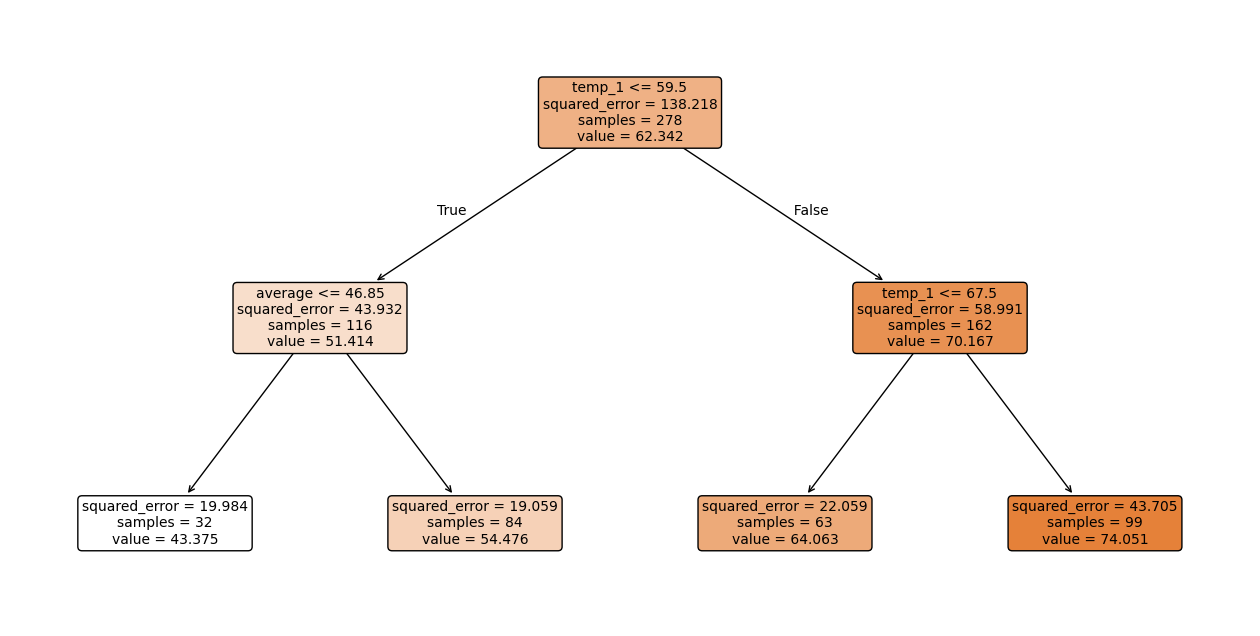

In [53]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [54]:
tree_reg_3 = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_reg_3.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 8. Vuelve a evaluar tu modelo

In [55]:
y_pred_3 = tree_reg_3.predict(X_test)

r2_3 = r2_score(y_test, y_pred_3)
mae_3 = mean_absolute_error(y_test, y_pred_3)
mse_3 = mean_squared_error(y_test, y_pred_3)
rmse_3 = np.sqrt(mse_3)
mape_3 = np.mean(np.abs((y_test - y_pred_3) / y_test)) * 100

print("R2 (depth=3):", r2_3)
print("MAE (depth=3):", mae_3)
print("MAPE (%) (depth=3):", mape_3)
print("MSE (depth=3):", mse_3)
print("RMSE (depth=3):", rmse_3)


R2 (depth=3): 0.8233792241290476
MAE (depth=3): 3.9065949299234783
MAPE (%) (depth=3): 6.201722569922846
MSE (depth=3): 24.69605405374038
RMSE (depth=3): 4.969512456342209


### 9. Vuelve a representar su árbol

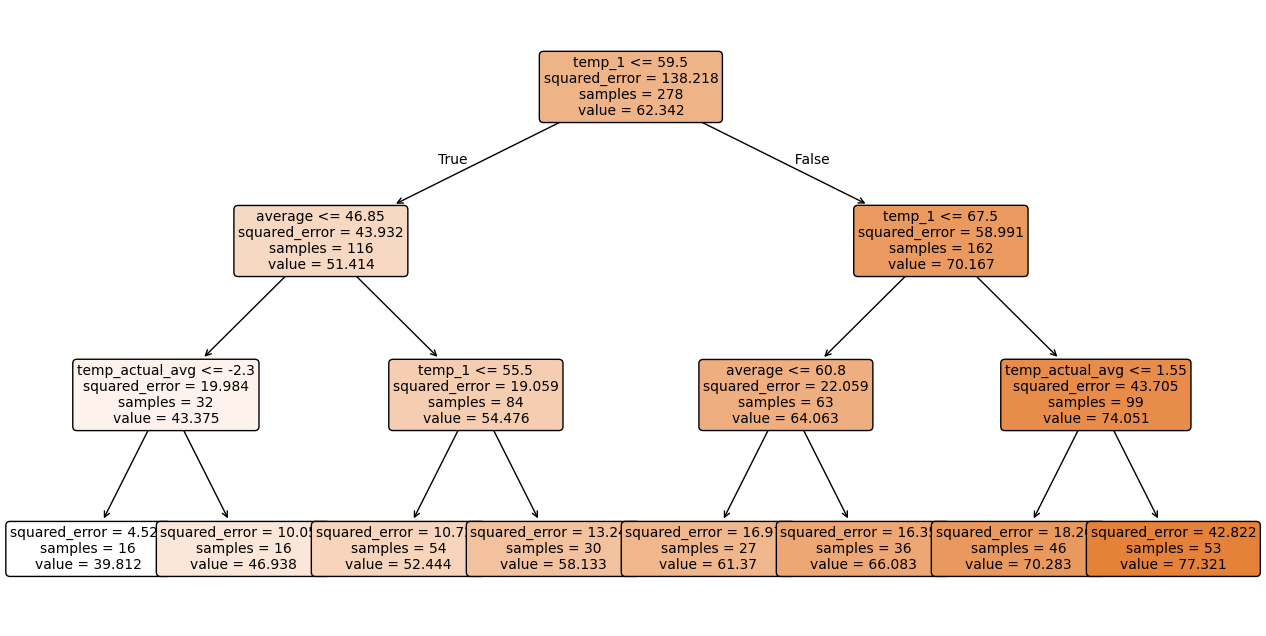

In [56]:
plt.figure(figsize=(16,8))
plot_tree(
    tree_reg_3,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [67]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

tree_reg_gs = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(estimator=tree_reg_gs,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [68]:

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score CV:", grid_search.best_score_)

best_reg = grid_search.best_estimator_

y_pred_best = best_reg.predict(X_test)

print("R2 test (best):", r2_score(y_test, y_pred_best))
print("MAE test (best):", mean_absolute_error(y_test, y_pred_best))
print("RMSE test (best):", np.sqrt(mean_squared_error(y_test, y_pred_best)))

mape_grid = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100
print("MAPE:", mape_grid)

mse_grid = mean_squared_error(y_test, y_pred_best)
print("MSE:", mse_grid)

Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score CV: 0.9214236191203156
R2 test (best): 0.8861845101175811
MAE test (best): 2.5428571428571427
RMSE test (best): 3.989271326230608
MAPE: 3.9395111106886156
MSE: 15.914285714285715


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [58]:
importances = best_reg.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_imp


temp_1             0.742778
average            0.146129
temp_actual_avg    0.099807
dif_temp           0.003860
temp_2             0.002948
month              0.002695
friend             0.001784
dtype: float64

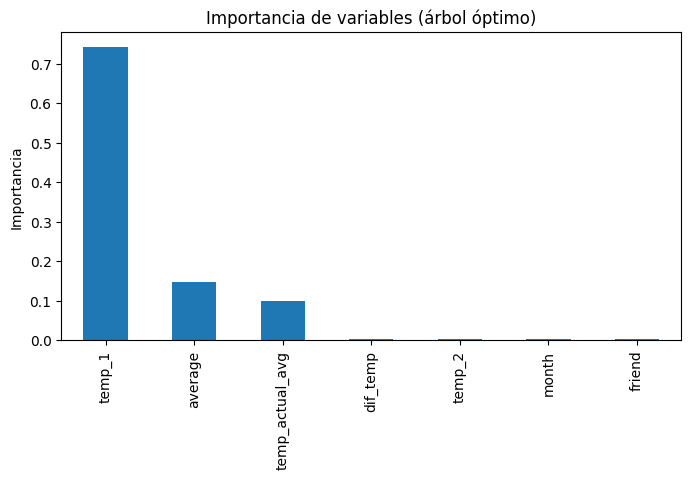

In [59]:
plt.figure(figsize=(8,4))
feat_imp.plot(kind="bar")
plt.title("Importancia de variables (árbol óptimo)")
plt.ylabel("Importancia")
plt.show()


### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [60]:
y_class = (df["actual"] > 59).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

param_grid_clf = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search_clf = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_clf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_clf.fit(X_train_c, y_train_c)

print("Mejores parámetros (clasificación):", grid_search_clf.best_params_)
print("Mejor accuracy CV:", grid_search_clf.best_score_)

best_clf = grid_search_clf.best_estimator_


Mejores parámetros (clasificación): {'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2}
Mejor accuracy CV: 0.9281818181818181


In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_c = best_clf.predict(X_test_c)

print("Accuracy test:", accuracy_score(y_test_c, y_pred_c))
print("Matriz de confusión:\n", confusion_matrix(y_test_c, y_pred_c))
print("Classification report:\n", classification_report(y_test_c, y_pred_c))


Accuracy test: 0.9714285714285714
Matriz de confusión:
 [[27  2]
 [ 0 41]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        29
           1       0.95      1.00      0.98        41

    accuracy                           0.97        70
   macro avg       0.98      0.97      0.97        70
weighted avg       0.97      0.97      0.97        70

